In [788]:
# 03 Kalman Model
# This notebook fits the dynamic hedge-ratio model for the selected pair.

In [789]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from filterpy.kalman import KalmanFilter

In [790]:
import importlib
import pipeline_config as cfg

# Reload shared config so notebook picks up edits without a kernel restart.
cfg = importlib.reload(cfg)

DATA_PATH = cfg.DATA_PATH
ENTRY_Z = cfg.ENTRY_Z
EXIT_Z = cfg.EXIT_Z
KALMAN_ALPHA_STATE_VAR = cfg.KALMAN_ALPHA_STATE_VAR
KALMAN_BETA_STATE_VAR = cfg.KALMAN_BETA_STATE_VAR
KALMAN_INIT_STATE_VAR = cfg.KALMAN_INIT_STATE_VAR
KALMAN_OBS_VAR_START = cfg.KALMAN_OBS_VAR_START
PAIR_X = cfg.PAIR_X
PAIR_Y = cfg.PAIR_Y
RESULTS_TABLES_PATH = cfg.RESULTS_TABLES_PATH
ROLLING_WINDOW = cfg.ROLLING_WINDOW
ensure_project_dirs = cfg.ensure_project_dirs
get_trade_stats = cfg.get_trade_stats
make_position = cfg.make_position

ensure_project_dirs()

data_path = DATA_PATH
results_path = RESULTS_TABLES_PATH

log_prices = pd.read_csv(data_path / "equity_log_prices.csv", index_col=0, parse_dates=True)
log_prices.index.name = "Datetime"

In [791]:
df = log_prices[[PAIR_Y, PAIR_X]].dropna().copy()
df.columns = ["y", "x"]
df.index.name = "Datetime"

assert df.index.is_monotonic_increasing
assert df.index.is_unique

df.head()


,y,x
Datetime,,
2025-06-26,4.940952,4.675775
2025-07-01,4.948745,4.668933
2025-07-11,5.013511,4.724050
2025-07-16,4.978190,4.695936
2025-07-21,4.976588,4.657980


In [792]:
X_OLS = sm.add_constant(df["x"])
ols = sm.OLS(df["y"], X_OLS).fit()
alpha0 = float(ols.params["const"])
beta0 = float(ols.params["x"])

pd.Series(
    {
        "alpha0": alpha0,
        "beta0": beta0,
        "kalman_alpha_state_var": KALMAN_ALPHA_STATE_VAR,
        "kalman_beta_state_var": KALMAN_BETA_STATE_VAR,
        "kalman_init_state_var": KALMAN_INIT_STATE_VAR,
        "kalman_obs_var_start": KALMAN_OBS_VAR_START,
    }
)


alpha0                    1.633187e+00
beta0                     7.158089e-01
kalman_alpha_state_var    1.000000e-08
kalman_beta_state_var     4.000000e-07
kalman_init_state_var     1.000000e-04
kalman_obs_var_start      1.000000e-06
dtype: float64

In [793]:
VOL_PROXY_SPAN = 10
VOL_SCALAR = 0.03

In [794]:
y = df["y"].to_numpy(dtype=float)
x = df["x"].to_numpy(dtype=float)
nobs = len(df)
obs_var = np.maximum(
    KALMAN_OBS_VAR_START
    + VOL_SCALAR
    * (
        (df["y"] - alpha0 - beta0 * df["x"])
        .ewm(span=VOL_PROXY_SPAN, adjust=False, min_periods=2)
        .var(bias=False)
        .fillna(KALMAN_OBS_VAR_START)
        .clip(lower=0.0)
        .to_numpy(dtype=float)
    ),
    0.0,
)

kf = KalmanFilter(dim_x=2, dim_z=1)
kf.x = np.array([[alpha0], [beta0]], dtype=float)
kf.P = np.diag([KALMAN_INIT_STATE_VAR, KALMAN_INIT_STATE_VAR])
kf.F = np.eye(2)
kf.Q = np.diag([KALMAN_ALPHA_STATE_VAR, KALMAN_BETA_STATE_VAR])

state = np.empty((nobs, 2))
state_pred = np.empty((nobs, 2))
innovation = np.empty(nobs)
innovation_var = np.empty(nobs)
zscore = np.empty(nobs)

for t in range(nobs):
    kf.H = np.array([[1.0, x[t]]])
    kf.R = np.array([[obs_var[t]]])

    kf.predict()
    state_pred[t] = kf.x[:, 0]

    innovation[t] = y[t] - float((kf.H @ kf.x)[0, 0])

    innovation_var[t] = max(float((kf.H @ kf.P @ kf.H.T + kf.R)[0, 0]), 0.0)
    zscore[t] = (
        innovation[t] / np.sqrt(innovation_var[t])
        if innovation_var[t] > 0
        else np.nan
    )

    kf.update(y[t])
    state[t] = kf.x[:, 0]

df = df.assign(
    alpha=state[:, 0],
    beta=state[:, 1],
    alpha_pred=state_pred[:, 0],
    beta_pred=state_pred[:, 1],
    innovation=innovation,
    innovation_var=innovation_var,
    innovation_std=np.sqrt(innovation_var),
    zscore=zscore,
)
df["innovation_std"] = df["innovation_std"].replace(0, np.nan)
df.head()

,y,x,alpha,beta,alpha_pred,beta_pred,innovation,innovation_var,innovation_std,zscore
Datetime,,,,,,,,,,
2025-06-26,4.940952,4.675775,1.631480,0.707795,1.633187,0.715809,-0.039196,0.002296,0.047917,-0.817999
2025-07-01,4.948745,4.668933,1.631666,0.709757,1.631480,0.707795,0.012618,0.000013,0.003629,3.476701
2025-07-11,5.013511,4.724050,1.630439,0.712823,1.631666,0.709757,0.028918,0.000025,0.005017,5.763921
2025-07-16,4.978190,4.695936,1.630439,0.712870,1.630439,0.712823,0.000381,0.000026,0.005054,0.075372
2025-07-21,4.976588,4.657980,1.631085,0.715343,1.630439,0.712870,0.025613,0.000031,0.005579,4.590666


In [795]:
df["spread"] = df["y"] - df["alpha"] - df["beta"] * df["x"]

In [796]:
df["signal"] = make_position(df["zscore"])
df[["alpha", "beta", "spread", "innovation", "zscore", "signal"]].tail()

,alpha,beta,spread,innovation,zscore,signal
Datetime,,,,,,
2026-02-26,1.633655,0.714080,0.011141,0.028132,5.591717,-1
2026-03-03,1.633440,0.716363,0.008967,0.020222,3.747163,-1
2026-03-13,1.632922,0.719199,0.016965,0.030767,4.928079,-1
2026-03-18,1.632699,0.720901,0.010889,0.019278,2.848517,-1
2026-03-23,1.632365,0.722456,0.010213,0.017806,2.489083,-1


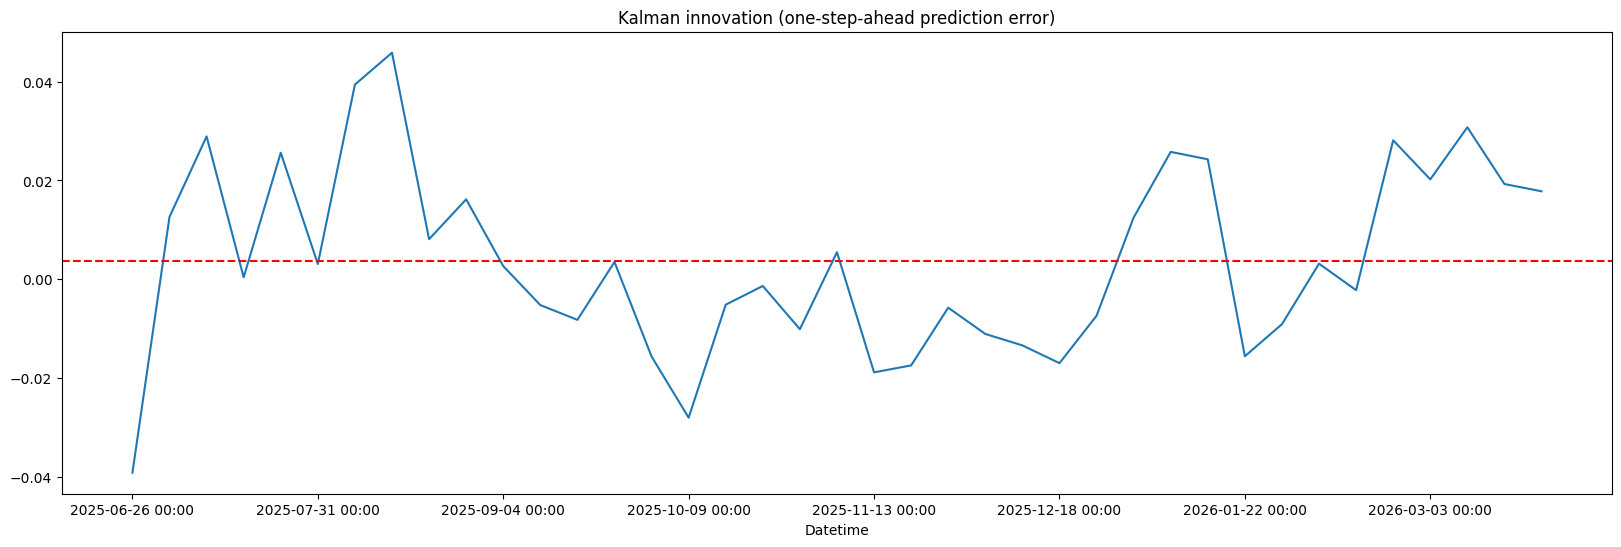

In [797]:
plot_spread = df["innovation"].copy()
plot_spread.index = plot_spread.index.strftime("%Y-%m-%d %H:%M")
plot_spread.plot(title="Kalman innovation (one-step-ahead prediction error)", figsize=(20, 6))
plt.axhline(plot_spread.mean(), linestyle="--", color="red")
plt.show()

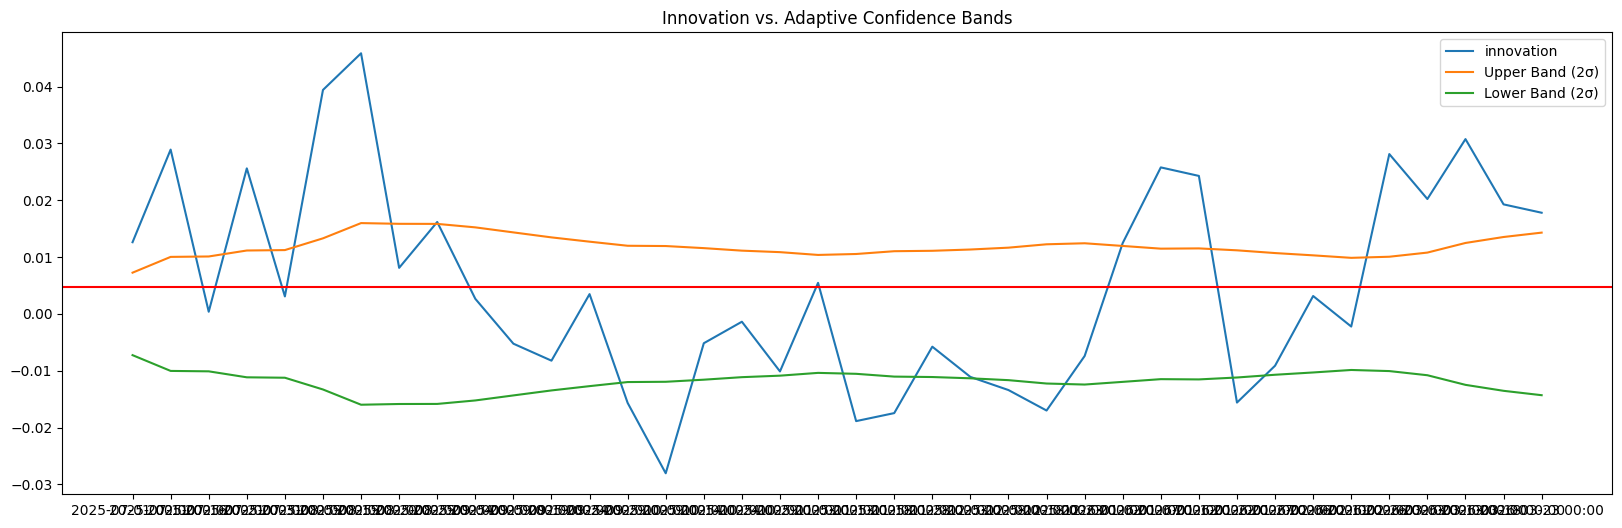

In [798]:
plot_df = df.iloc[1:].copy()
plot_df = plot_df[plot_df.index.dayofweek < 5]
plot_df = plot_df[['innovation', 'innovation_std']].dropna()
plot_idx = pd.to_datetime(plot_df.index, errors='coerce')
plot_df = plot_df.loc[plot_idx.notna()].copy()
plot_df.index = plot_idx[plot_idx.notna()].strftime('%Y-%m-%d %H:%M')

plt.figure(figsize=(20, 6))
if plot_df.empty:
    print('No weekday innovation data to plot after filtering.')
else:
    plt.plot(plot_df.index, plot_df['innovation'], label='innovation')
    plt.plot(plot_df.index, 2 * plot_df['innovation_std'], label='Upper Band (2σ)')
    plt.plot(plot_df.index, -2 * plot_df['innovation_std'], label='Lower Band (2σ)')
    plt.axhline(plot_df['innovation'].mean(), color='red', linestyle='-')
    plt.title('Innovation vs. Adaptive Confidence Bands')
    plt.legend()
    plt.show()

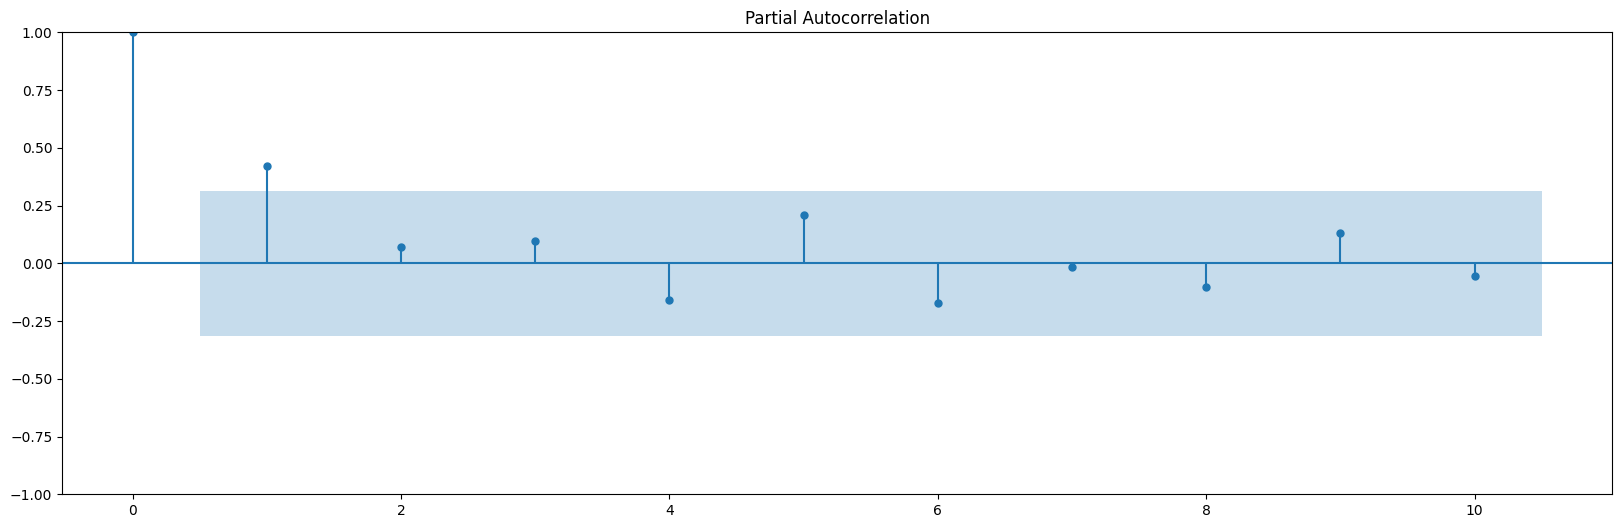

In [799]:
from statsmodels.graphics.tsaplots import plot_pacf

clean_innovation = df["innovation"].dropna()
plot_pacf(clean_innovation, lags=10)
plt.gcf().set_size_inches(20, 6)
plt.show()

In [800]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_results = acorr_ljungbox(clean_innovation, lags=[10], return_df=True)

print(lb_results)

p_val = lb_results['lb_pvalue'].iloc[0]
print(f"\nP-Value: {p_val:.4f}")

if p_val > 0.05:
    print("statistically white noise")
else:
    print(" Autocorrelation")

      lb_stat  lb_pvalue
10  13.307462   0.206986

P-Value: 0.2070
statistically white noise


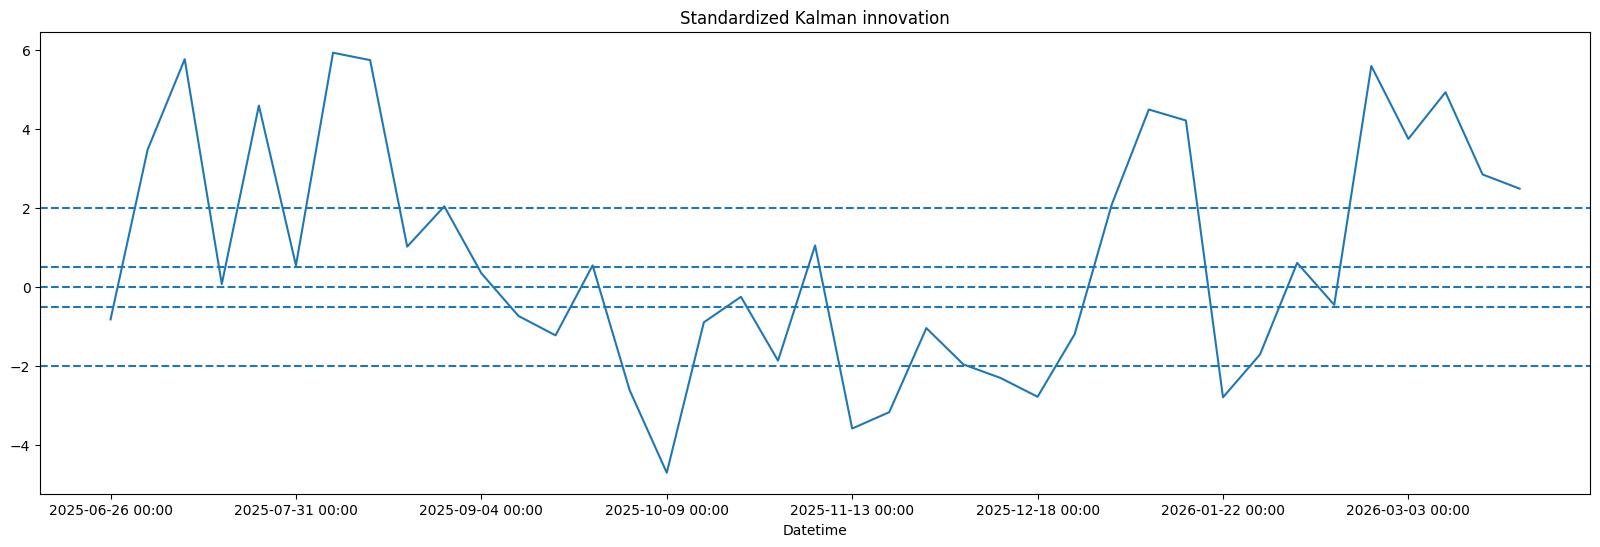

In [801]:
plot_z = df["zscore"].copy()
plot_z.index = plot_z.index.strftime("%Y-%m-%d %H:%M")
plot_z.plot(title="Standardized Kalman innovation", figsize=(20, 6))
for level in [ENTRY_Z, -ENTRY_Z, EXIT_Z, -EXIT_Z, 0]:
    plt.axhline(level, linestyle="--")
plt.show()


In [802]:
z_lag = df['spread'].shift(1)
z_delta = df['spread'].diff()
data = pd.DataFrame({'delta': z_delta, 'lag': z_lag}).dropna()
X = sm.add_constant(data['lag'])
model = sm.OLS(data['delta'], X).fit()
lambda_val = model.params['lag'] #decay-constant
if lambda_val < 0:
    half_life = -np.log(2) / lambda_val # half-Life: -ln(2) / lambda
    print(f"Mean Reversion with decay_const gamma: {lambda_val:.2f}")
    print(f"Theta: {float(1 + lambda_val):.2f}") # theta = 1 + gamma; theta == AR(1) coefficient
    print(f"Half-Life: {half_life:.2f} bars")
else:
    print("Spread is divergent")

Mean Reversion with decay_const gamma: -0.48
Theta: 0.52
Half-Life: 1.45 bars


In [803]:
required_columns = [
    "y",
    "x",
    "alpha",
    "beta",
    "spread",
    "alpha_pred",
    "beta_pred",
    "zscore",
    "innovation",
    "innovation_var",
    "innovation_std",
    "signal",
]

assert all(column in df.columns for column in required_columns)

df[required_columns].tail()

,y,x,alpha,beta,spread,alpha_pred,beta_pred,zscore,innovation,innovation_var,innovation_std,signal
Datetime,,,,,,,,,,,,
2026-02-26,5.215805,5.000854,1.633655,0.714080,0.011141,1.633381,0.710737,5.591717,0.028132,0.000025,0.005031,-1
2026-03-03,5.240529,5.022761,1.633440,0.716363,0.008967,1.633655,0.714080,3.747163,0.020222,0.000029,0.005397,-1
2026-03-13,5.282290,5.050625,1.632922,0.719199,0.016965,1.633440,0.716363,4.928079,0.030767,0.000039,0.006243,-1
2026-03-18,5.291343,5.059997,1.632699,0.720901,0.010889,1.632922,0.719199,2.848517,0.019278,0.000046,0.006768,-1
2026-03-23,5.323741,5.095344,1.632365,0.722456,0.010213,1.632699,0.720901,2.489083,0.017806,0.000051,0.007153,-1


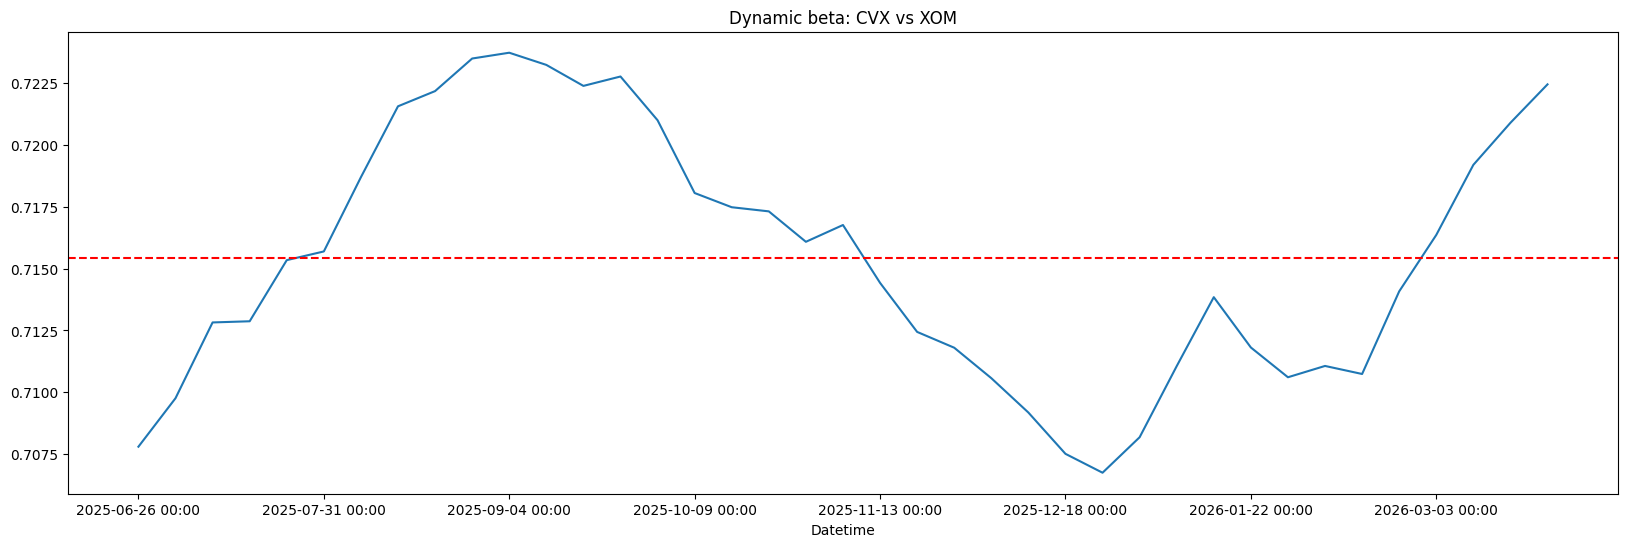

In [804]:
plot_beta = df["beta"].copy()
plot_beta.index = plot_beta.index.strftime("%Y-%m-%d %H:%M")
plot_beta.plot(title=f"Dynamic beta: {PAIR_Y} vs {PAIR_X}", figsize=(20, 6))
plt.axhline(plot_beta.mean(), linestyle="--", color="red")
plt.show()

In [805]:
df.to_csv(results_path / f"{PAIR_Y}_{PAIR_X}_kalman_model.csv", index_label="Datetime")

In [806]:
get_trade_stats(df)

{'Total Trades': 6,
 'Gross PnL': np.float64(0.05686),
 'Net PnL': np.float64(0.05036),
 'Avg Profit/Trade (Gross)': np.float64(0.00948),
 'Fee (Round-trip)': 0.001}